In [ ]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Import Dataset
df = pd.read_csv('/content/drive/MyDrive/What I do in Collage/BK/Assignment/Dataset/titanic/train.csv')


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
drop_col = ['PassengerId','Name','Ticket','Cabin']
df.drop(drop_col,axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
print("--- 1. CEK DATA DUPLIKAT ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat dalam dataset: {jumlah_duplikat}")

print("\n--- 2. CEK MISSING VALUES (Kekosongan Data) ---")
# Hitung jumlah missing value per kolom
missing_data = df.isnull().sum()

# Tampilkan hanya kolom yang punya missing value, biar rapi
print(missing_data[missing_data > 0])

# Visualisasi persentase missing value (opsional, tapi bikin laporan makin keren)
missing_percentage = (missing_data[missing_data > 0] / len(df)) * 100
print("\n--- Persentase Kekosongan (%) ---")
print(missing_percentage.round(2))

--- 1. CEK DATA DUPLIKAT ---
Jumlah baris duplikat dalam dataset: 111

--- 2. CEK MISSING VALUES (Kekosongan Data) ---
Age         177
Embarked      2
dtype: int64

--- Persentase Kekosongan (%) ---
Age         19.87
Embarked     0.22
dtype: float64



--- 3. BUKTI VISUAL OUTLIER (SEMUA FITUR NUMERIK) ---


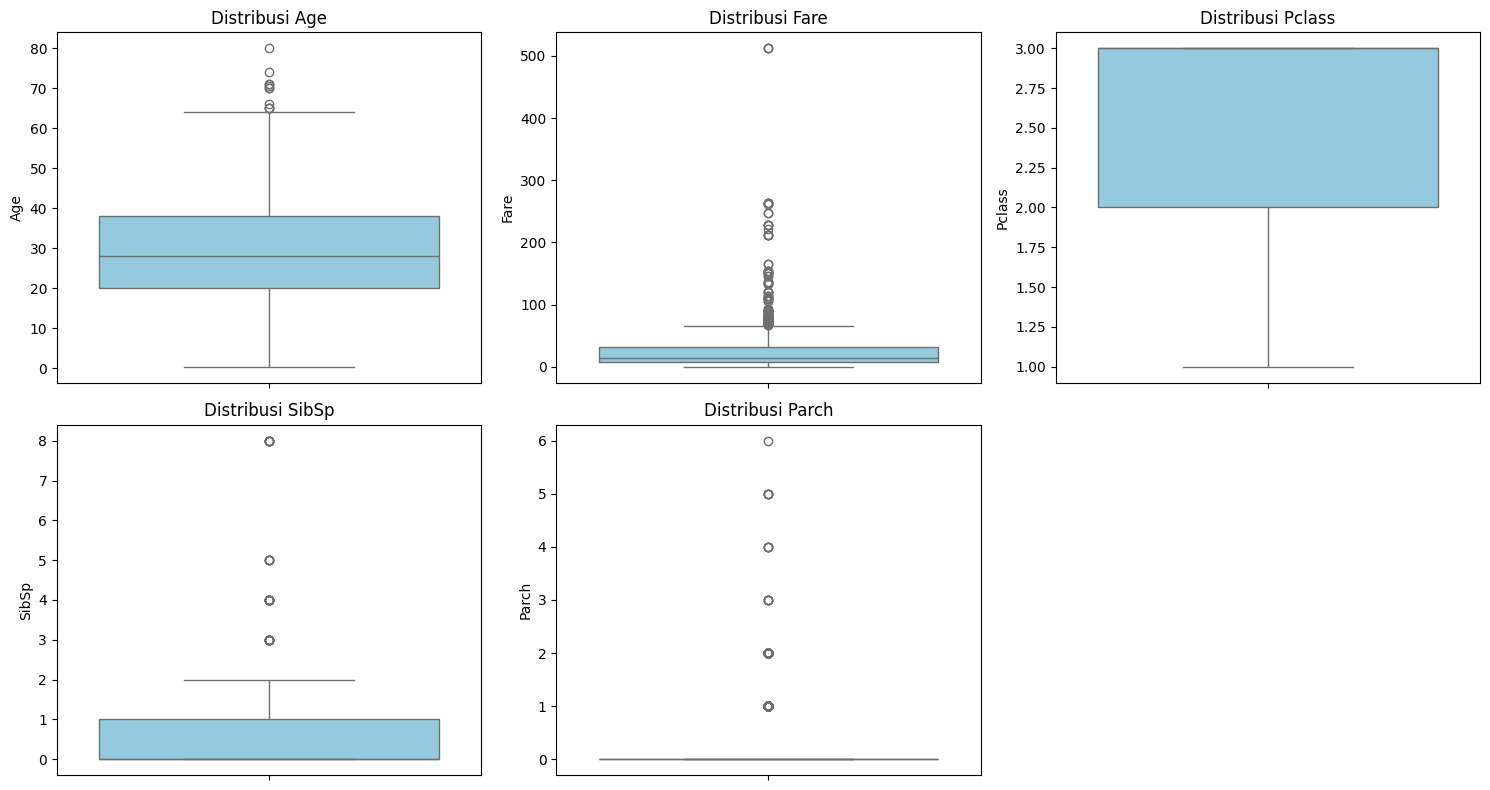


--- Cek Angka Tertinggi (Max) per Kolom ---
Age: 80.0
Fare: 512.3292
Pclass: 3
SibSp: 8
Parch: 6


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- 3. BUKTI VISUAL OUTLIER (SEMUA FITUR NUMERIK) ---")

# Daftar kolom numerik yang mau kita intip
num_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']

# Bikin kanvas gambar yang agak gede (15x8) biar grafiknya nggak dempetan
plt.figure(figsize=(15, 8))

# Looping untuk membuat subplot secara otomatis
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1) # Bikin pola grid 2 baris, 3 kolom
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

# Tampilkan angka max buat bukti tambahan
print("\n--- Cek Angka Tertinggi (Max) per Kolom ---")
for col in num_cols:
    print(f"{col}: {df[col].max()}")

--- BUKTI DATA KOTOR SEBELUM EKSPERIMEN ---
Jumlah baris duplikat di awal: 111
Missing Values:
 Age         177
Embarked      2
dtype: int64
---------------------------------------- 

=== HASIL EVALUASI EKSPERIMEN 1 (SPLIT-FIRST) ===

Model: Logistic Regression
Accuracy : 0.8103 | Precision: 0.7910 | Recall: 0.7361 | F1-Score: 0.7626


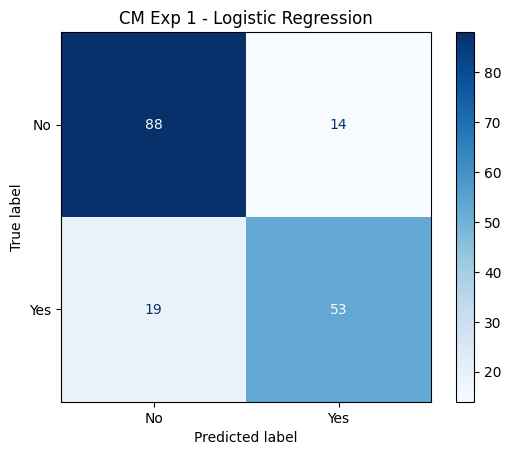

--------------------------------------------------
Model: KNN
Accuracy : 0.8103 | Precision: 0.8000 | Recall: 0.7222 | F1-Score: 0.7591


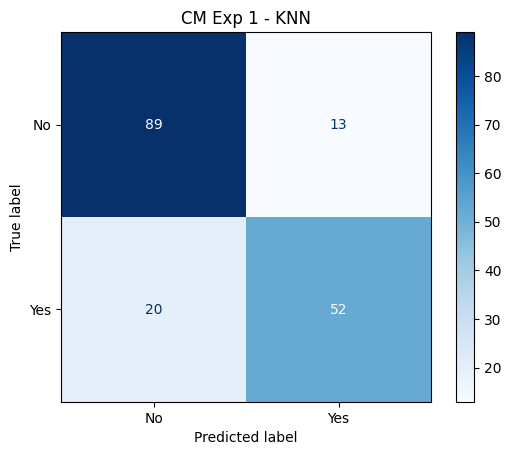

--------------------------------------------------
Model: Random Forest
Accuracy : 0.8046 | Precision: 0.7568 | Recall: 0.7778 | F1-Score: 0.7671


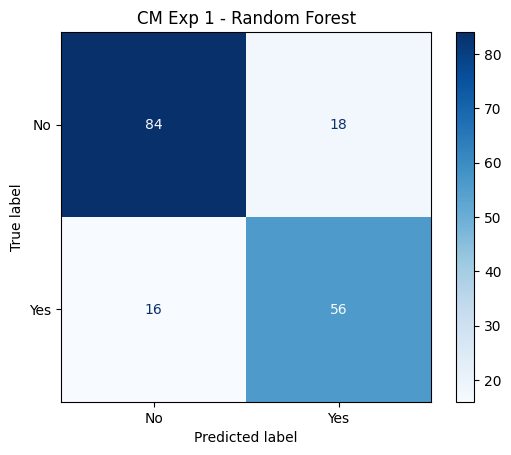

--------------------------------------------------


In [ ]:
# ==========================================
# 0. EKSPLORASI DATA KOTOR
# ==========================================
print("--- BUKTI DATA KOTOR SEBELUM EKSPERIMEN ---")
print(f"Jumlah baris duplikat di awal: {df.duplicated().sum()}")
print("Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("-" * 40, "\n")

# Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Survived'])
y = df['Survived']

# ==========================================
# 1. SPLIT DATA TERLEBIH DAHULU (Eksperimen 1)
# ==========================================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Copy data untuk menghindari SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()
y_train = y_train.copy()
y_test = y_test.copy()

# ==========================================
# 2. PREPROCESSING (Diterapkan Setelah Split)
# ==========================================

# A. PENANGANAN DATA DUPLIKAT (Secara Terpisah)
# Cari index baris yang duplikat di Train, lalu hapus di X_train DAN y_train
train_dupes = X_train.duplicated()
X_train = X_train[~train_dupes]
y_train = y_train[~train_dupes]

# Cari index baris yang duplikat di Test, lalu hapus di X_test DAN y_test
test_dupes = X_test.duplicated()
X_test = X_test[~test_dupes]
y_test = y_test[~test_dupes]

# B. PENANGANAN MISSING VALUE
# FIT: Hitung median & modus murni DARI TRAIN SAJA
age_median = X_train['Age'].median()
embarked_mode = X_train['Embarked'].mode()[0]

# TRANSFORM: Aplikasikan ke TRAIN dan TEST
X_train['Age'] = X_train['Age'].fillna(age_median)
X_test['Age'] = X_test['Age'].fillna(age_median)

X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

# C. PENANGANAN OUTLIER (Menggunakan metode IQR pada kolom 'Fare')
# FIT: Hitung rentang IQR murni DARI TRAIN SAJA
Q1 = X_train['Fare'].quantile(0.25)
Q3 = X_train['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# TRANSFORM: Batasi nilai (capping) pada TRAIN dan TEST
import numpy as np
X_train['Fare'] = np.clip(X_train['Fare'], lower_bound, upper_bound)
X_test['Fare'] = np.clip(X_test['Fare'], lower_bound, upper_bound)

# D. FEATURE SCALING DAN ENCODING
from sklearn.preprocessing import StandardScaler, OneHotEncoder
cat_cols = ['Sex', 'Embarked']
num_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']

scaler = StandardScaler()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# FIT & TRANSFORM pada TRAIN
train_num_scaled = scaler.fit_transform(X_train[num_cols])
train_cat_encoded = ohe.fit_transform(X_train[cat_cols])

# HANYA TRANSFORM pada TEST (Model tidak boleh 'belajar' skala dari Test)
test_num_scaled = scaler.transform(X_test[num_cols])
test_cat_encoded = ohe.transform(X_test[cat_cols])

# Gabungkan kembali array numerik dan kategorikal
X_train_final = np.hstack((train_num_scaled, train_cat_encoded))
X_test_final = np.hstack((test_num_scaled, test_cat_encoded))


# ==========================================
# 3. TRAINING & EVALUASI
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Simpan hasil untuk visualisasi bar chart nanti
hasil_eksperimen_1 = {}

print("=== HASIL EVALUASI EKSPERIMEN 1 (SPLIT-FIRST) ===\n")
for nama_model, model in models.items():
    # Training
    model.fit(X_train_final, y_train)

    # Prediksi
    y_pred = model.predict(X_test_final)

    # Hitung Metrik
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    hasil_eksperimen_1[nama_model] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

    # Tampilkan Metrik Teks
    print(f"Model: {nama_model}")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'CM Exp 1 - {nama_model}')
    plt.show()
    print("-" * 50)

=== HASIL EVALUASI EKSPERIMEN 2 (PREPROCESS-FIRST / DATA LEAKAGE) ===

Model: Logistic Regression
Accuracy : 0.7756 | Precision: 0.7344 | Recall: 0.7231 | F1-Score: 0.7287


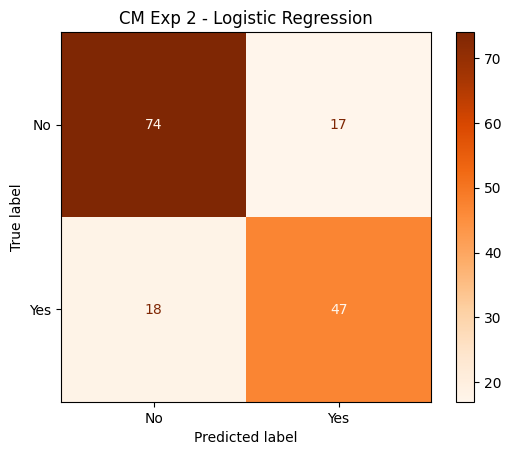

--------------------------------------------------
Model: KNN
Accuracy : 0.7564 | Precision: 0.7143 | Recall: 0.6923 | F1-Score: 0.7031


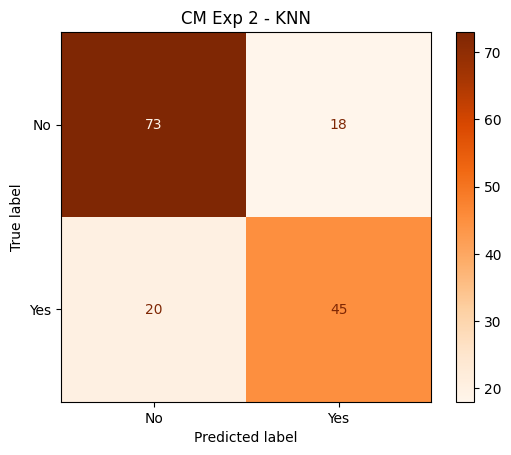

--------------------------------------------------
Model: Random Forest
Accuracy : 0.7949 | Precision: 0.7797 | Recall: 0.7077 | F1-Score: 0.7419


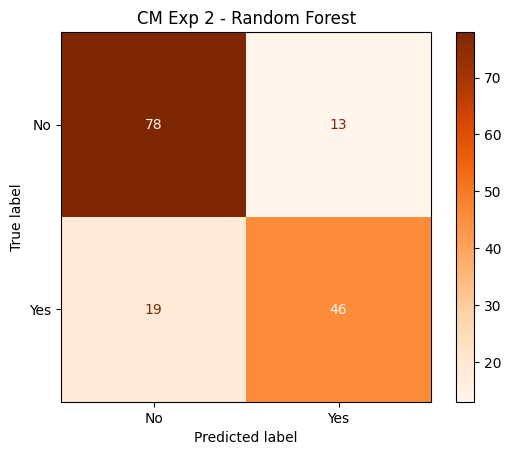

--------------------------------------------------


In [ ]:
# ==========================================
# 0. LOAD DATA ULANG (Biar Fresh)
# ==========================================
df2 = pd.read_csv('/content/drive/MyDrive/What I do in Collage/BK/Assignment/Dataset/titanic/train.csv')
df2 = df2.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# ==========================================
# 1. PREPROCESSING (DILAKUKAN SEBELUM SPLIT) -> Ini sumber Data Leakage!
# ==========================================

# A. PENANGANAN DUPLIKAT (Hapus duplikat di seluruh dataset sekaligus)
df2 = df2.drop_duplicates()

# Pisahkan Fitur (X) dan Target (y)
X2 = df2.drop(columns=['Survived'])
y2 = df2['Survived']

# B. PENANGANAN MISSING VALUE
# Menghitung median dan modus dari KESELURUHAN DATA (Train + Test)
age_median_leak = X2['Age'].median()
embarked_mode_leak = X2['Embarked'].mode()[0]

X2['Age'] = X2['Age'].fillna(age_median_leak)
X2['Embarked'] = X2['Embarked'].fillna(embarked_mode_leak)

# C. PENANGANAN OUTLIER
# Menghitung IQR dari KESELURUHAN DATA
Q1_leak = X2['Fare'].quantile(0.25)
Q3_leak = X2['Fare'].quantile(0.75)
IQR_leak = Q3_leak - Q1_leak
lower_bound_leak = Q1_leak - 1.5 * IQR_leak
upper_bound_leak = Q3_leak + 1.5 * IQR_leak

X2['Fare'] = np.clip(X2['Fare'], lower_bound_leak, upper_bound_leak)

# D. FEATURE SCALING & ENCODING
cat_cols = ['Sex', 'Embarked']
num_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']

scaler2 = StandardScaler()
ohe2 = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# FIT & TRANSFORM pada KESELURUHAN DATA
X2_num_scaled = scaler2.fit_transform(X2[num_cols])
X2_cat_encoded = ohe2.fit_transform(X2[cat_cols])

# Gabungkan
X2_final = np.hstack((X2_num_scaled, X2_cat_encoded))


# ==========================================
# 2. SPLIT DATA (Dilakukan SETELAH Preprocessing)
# ==========================================
# Kita pakai random_state yang sama (42) dan rasio yang sama (0.2) agar apple-to-apple dengan Exp 1
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2_final, y2, test_size=0.2, random_state=42)


# ==========================================
# 3. TRAINING & EVALUASI
# ==========================================
models2 = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Simpan hasil untuk visualisasi bar chart nanti
hasil_eksperimen_2 = {}

print("=== HASIL EVALUASI EKSPERIMEN 2 (PREPROCESS-FIRST / DATA LEAKAGE) ===\n")
for nama_model, model in models2.items():
    # Training
    model.fit(X_train2, y_train2)

    # Prediksi
    y_pred2 = model.predict(X_test2)

    # Hitung Metrik
    acc2 = accuracy_score(y_test2, y_pred2)
    prec2 = precision_score(y_test2, y_pred2)
    rec2 = recall_score(y_test2, y_pred2)
    f1_2 = f1_score(y_test2, y_pred2)

    hasil_eksperimen_2[nama_model] = {'Accuracy': acc2, 'Precision': prec2, 'Recall': rec2, 'F1-Score': f1_2}

    # Tampilkan Metrik Teks
    print(f"Model: {nama_model}")
    print(f"Accuracy : {acc2:.4f} | Precision: {prec2:.4f} | Recall: {rec2:.4f} | F1-Score: {f1_2:.4f}")

    # Visualisasi Confusion Matrix
    cm2 = confusion_matrix(y_test2, y_pred2)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['No', 'Yes'])
    disp2.plot(cmap='Oranges', values_format='d') # Pakai warna Oranye biar beda sama Exp 1 (Biru)
    plt.title(f'CM Exp 2 - {nama_model}')
    plt.show()
    print("-" * 50)

=== MEMULAI EKSPERIMEN 3: HYPERPARAMETER TUNING (GRID SEARCH) ===

Mencari parameter terbaik untuk Logistic Regression...
Setingan Terbaik: {'C': 0.1, 'solver': 'lbfgs'}
Accuracy : 0.8103 | Precision: 0.7910 | Recall: 0.7361 | F1-Score: 0.7626


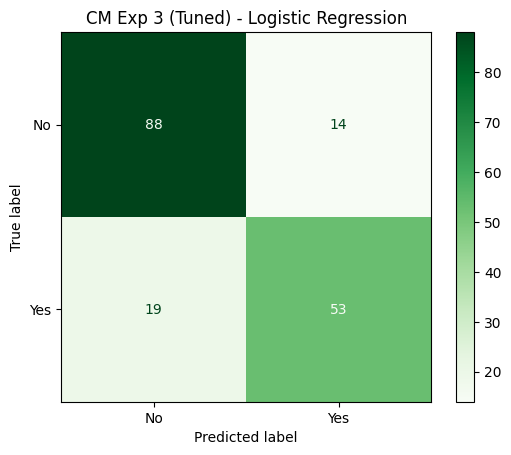

------------------------------------------------------------
Mencari parameter terbaik untuk KNN...
Setingan Terbaik: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Accuracy : 0.8161 | Precision: 0.8125 | Recall: 0.7222 | F1-Score: 0.7647


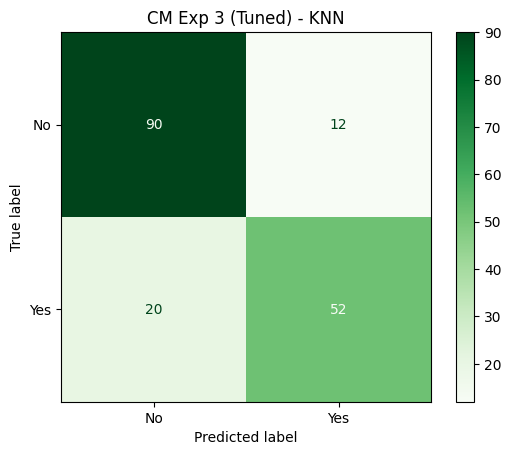

------------------------------------------------------------
Mencari parameter terbaik untuk Random Forest...
Setingan Terbaik: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy : 0.8046 | Precision: 0.7969 | Recall: 0.7083 | F1-Score: 0.7500


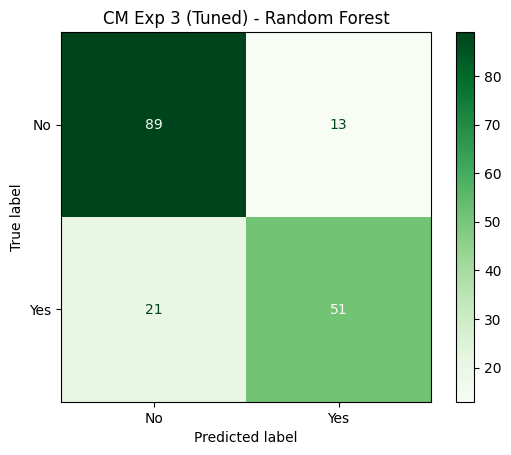

------------------------------------------------------------


In [ ]:
from sklearn.model_selection import GridSearchCV

print("=== MEMULAI EKSPERIMEN 3: HYPERPARAMETER TUNING (GRID SEARCH) ===\n")

# 1. Siapkan 'Knop' (Hyperparameter Grid) untuk masing-masing model
# Komputer akan mencoba SEMUA kombinasi angka di dalam kurung siku ini

param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],          # Kekuatan regularisasi (mencegah overfitting)
    'solver': ['lbfgs', 'liblinear']       # Algoritma optimasinya
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],   # Jumlah tetangga terdekat yang dilihat
    'weights': ['uniform', 'distance'],    # Apakah tetangga yang dekat bobotnya lebih besar?
    'metric': ['euclidean', 'manhattan']   # Cara ngitung jaraknya
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],        # Jumlah pohon yang ditanam
    'max_depth': [None, 5, 10, 20],        # Kedalaman maksimal tiap pohon
    'min_samples_split': [2, 5, 10]        # Minimal data untuk memecah cabang pohon
}

# Gabungkan grid dan model dasar ke dalam dictionary
models_to_tune = {
    'Logistic Regression': (LogisticRegression(random_state=42, max_iter=1000), param_grid_logreg),
    'KNN': (KNeighborsClassifier(), param_grid_knn),
    'Random Forest': (RandomForestClassifier(random_state=42), param_grid_rf)
}

# Siapkan wadah untuk menyimpan skor Eksperimen 3
hasil_eksperimen_3 = {}

for nama_model, (model, param_grid) in models_to_tune.items():
    print(f"Mencari parameter terbaik untuk {nama_model}...")

    # 2. Proses Grid Search CV (Cross-Validation = 5)
    # n_jobs=-1 artinya kita nyuruh komputer pakai semua core CPU biar cepat!
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

    # Training dengan nyobain semua kombinasi (Pakai X_train_final dari Eksperimen 1)
    grid_search.fit(X_train_final, y_train)

    # Ambil model dengan setingan terbaik
    best_model = grid_search.best_estimator_
    print(f"Setingan Terbaik: {grid_search.best_params_}")

    # 3. Prediksi ke Data Test menggunakan Model Terbaik
    y_pred3 = best_model.predict(X_test_final)

    # Hitung Metrik Evaluasi
    acc3 = accuracy_score(y_test, y_pred3)
    prec3 = precision_score(y_test, y_pred3)
    rec3 = recall_score(y_test, y_pred3)
    f1_3 = f1_score(y_test, y_pred3)

    hasil_eksperimen_3[nama_model] = {'Accuracy': acc3, 'Precision': prec3, 'Recall': rec3, 'F1-Score': f1_3}

    # Tampilkan Metrik Teks
    print(f"Accuracy : {acc3:.4f} | Precision: {prec3:.4f} | Recall: {rec3:.4f} | F1-Score: {f1_3:.4f}")

    # Visualisasi Confusion Matrix
    cm3 = confusion_matrix(y_test, y_pred3)
    disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['No', 'Yes'])
    disp3.plot(cmap='Greens', values_format='d') # Pakai warna Hijau biar beda dari Exp 1 dan 2
    plt.title(f'CM Exp 3 (Tuned) - {nama_model}')
    plt.show()
    print("-" * 60)

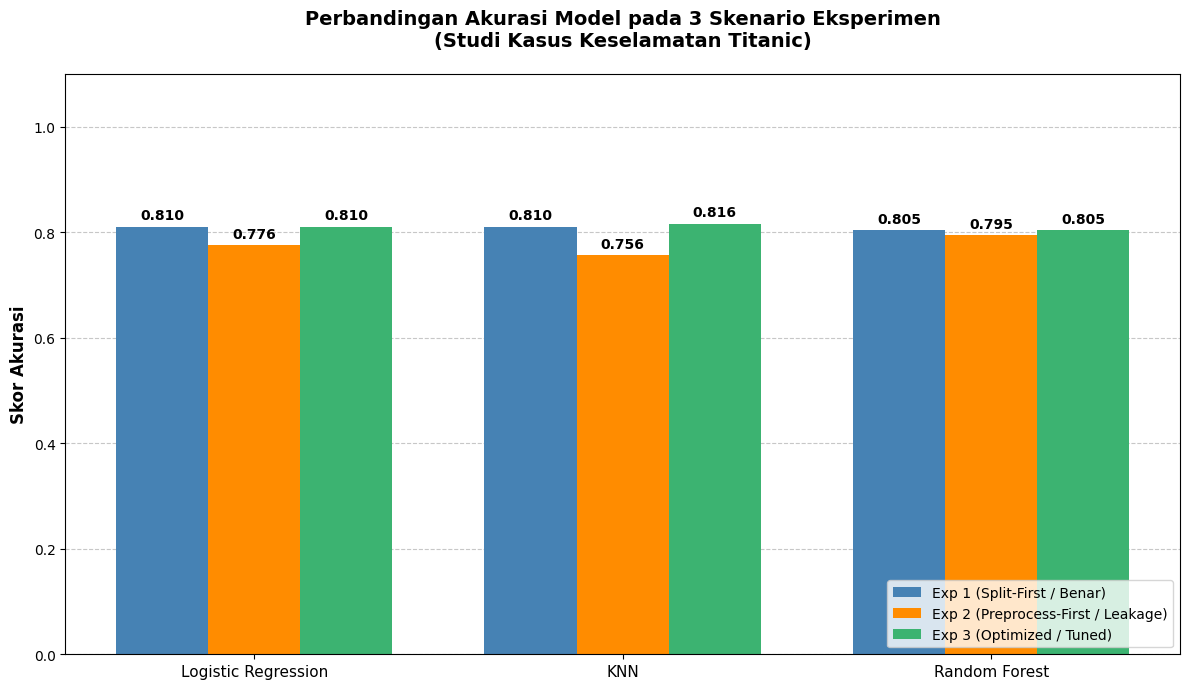

In [ ]:
# Ambil nama-nama model
daftar_model = ['Logistic Regression', 'KNN', 'Random Forest']

# Ekstrak nilai Akurasi (Accuracy) dari masing-masing dictionary hasil eksperimen
# (Lo juga bisa ganti 'Accuracy' jadi 'F1-Score' kalau mau nampilin metrik lain)
akurasi_exp1 = [hasil_eksperimen_1[m]['Accuracy'] for m in daftar_model]
akurasi_exp2 = [hasil_eksperimen_2[m]['Accuracy'] for m in daftar_model]
akurasi_exp3 = [hasil_eksperimen_3[m]['Accuracy'] for m in daftar_model]

# Pengaturan posisi batang (bar) di grafik
x = np.arange(len(daftar_model))
lebar_batang = 0.25

# Membuat Kanvas
fig, ax = plt.subplots(figsize=(12, 7))

# Menggambar Batang (warna disamakan dengan tema Confusion Matrix kita)
batang1 = ax.bar(x - lebar_batang, akurasi_exp1, lebar_batang, label='Exp 1 (Split-First / Benar)', color='steelblue')
batang2 = ax.bar(x, akurasi_exp2, lebar_batang, label='Exp 2 (Preprocess-First / Leakage)', color='darkorange')
batang3 = ax.bar(x + lebar_batang, akurasi_exp3, lebar_batang, label='Exp 3 (Optimized / Tuned)', color='mediumseagreen')

# Mempercantik Grafik (Menambahkan label, judul, dll)
ax.set_ylabel('Skor Akurasi', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Akurasi Model pada 3 Skenario Eksperimen\n(Studi Kasus Keselamatan Titanic)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(daftar_model, fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1) # Set batas atas Y ke 1.1 biar ada ruang buat angka di atas batang

# Fungsi untuk memunculkan angka di atas setiap batang grafik
def tambah_label_angka(batang_grafik):
    for batang in batang_grafik:
        tinggi = batang.get_height()
        ax.annotate(f'{tinggi:.3f}',
                    xy=(batang.get_x() + batang.get_width() / 2, tinggi),
                    xytext=(0, 3),  # 3 poin geser ke atas dari pucuk batang
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Aplikasikan fungsi label ke ketiga grup batang
tambah_label_angka(batang1)
tambah_label_angka(batang2)
tambah_label_angka(batang3)

# Munculkan garis background tipis biar gampang dibaca
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()